In [1]:
import os, time, random, zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import silhouette_score, f1_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import pandas as pd

CORESET_DIR   = "/kaggle/input/datasets/anubhaviitmadras/exp2-results/coresets"
EXP2_AGG_PATH = "/kaggle/input/datasets/anubhaviitmadras/exp2-results/exp2_aggregated.csv"
os.makedirs("results", exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────
SEEDS         = [42, 123, 456]
BUDGET        = 5000
BATCH_SIZE    = 256
EPOCHS        = 40
LR            = 0.001
WD            = 0.0001
PRUNING_RATES = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]
SELECTORS     = ["random", "margin", "kcenter", "gaussian"]
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Seed ───────────────────────────────────────────────────────────
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ── Data ───────────────────────────────────────────────────────────
def get_dataloaders(dataset_name="cifar10"):
    mean = (0.4914, 0.4822, 0.4465) if dataset_name == "cifar10" else (0.5071, 0.4867, 0.4408)
    std  = (0.2470, 0.2435, 0.2616) if dataset_name == "cifar10" else (0.2675, 0.2565, 0.2761)
    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    DS = torchvision.datasets.CIFAR10 if dataset_name == "cifar10" else torchvision.datasets.CIFAR100
    num_classes = 10 if dataset_name == "cifar10" else 100
    train_ds    = DS(root="./data", train=True,  download=True, transform=train_tf)
    test_ds     = DS(root="./data", train=False, download=True, transform=test_tf)
    test_loader = DataLoader(test_ds, batch_size=512, shuffle=False,
                             num_workers=2, pin_memory=True)
    return train_ds, test_loader, num_classes

# ── Model ──────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*32*32, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),     nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),     nn.BatchNorm1d(128), nn.ReLU(),
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x, return_embedding=False):
        emb = self.features(x)
        if return_embedding:
            return emb
        return self.classifier(emb)

# ── Train ──────────────────────────────────────────────────────────
def train_model(model, loader, epochs=EPOCHS, device=DEVICE):
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)
    criterion = nn.CrossEntropyLoss()
    model.to(device)
    for epoch in range(epochs):
        model.train()
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
        scheduler.step()

# ── Embeddings ─────────────────────────────────────────────────────
@torch.no_grad()
def extract_embeddings(model, dataset, device=DEVICE, batch_size=512):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)
    embs = []
    for X, _ in loader:
        embs.append(model(X.to(device), return_embedding=True).cpu())
    return torch.cat(embs).numpy()

# ── Pruning ────────────────────────────────────────────────────────
def apply_pruning(model, amount):
    if amount == 0.0:
        return model
    for _, module in model.named_modules():
        if isinstance(module, nn.Linear):
            prune.l1_unstructured(module, name="weight", amount=amount)
            prune.remove(module, "weight")
    return model

print("All helpers loaded ✓")

Device: cuda
All helpers loaded ✓


In [2]:
def compute_silhouette(embeddings, labels, n_sample=5000, seed=42):
    rng       = np.random.default_rng(seed)
    classes   = np.unique(labels)
    per_class = n_sample // len(classes)
    idx_list  = []
    for c in classes:
        class_idx = np.where(labels == c)[0]
        chosen    = rng.choice(class_idx,
                               size=min(per_class, len(class_idx)),
                               replace=False)
        idx_list.append(chosen)
    idx_sub = np.concatenate(idx_list)
    return float(silhouette_score(embeddings[idx_sub], labels[idx_sub], metric="euclidean"))


def compute_coverage_radius(embeddings, selected_indices):
    selected   = embeddings[selected_indices]
    mask       = np.ones(len(embeddings), dtype=bool)
    mask[selected_indices] = False
    unselected = embeddings[mask]
    chunk_size = 2000
    max_r      = 0.0
    for i in range(0, len(unselected), chunk_size):
        chunk = unselected[i:i + chunk_size]
        dists = np.linalg.norm(chunk[:, None, :] - selected[None, :, :], axis=2)
        max_r = max(max_r, dists.min(axis=1).max())
    return float(max_r)


def kcenter_greedy(embeddings, budget, seed=42):
    rng       = np.random.default_rng(seed)
    first     = int(rng.integers(0, len(embeddings)))
    selected  = [first]
    min_dists = np.full(len(embeddings), np.inf)
    for _ in range(budget - 1):
        new_d     = np.linalg.norm(embeddings - embeddings[selected[-1]], axis=1)
        min_dists = np.minimum(min_dists, new_d)
        selected.append(int(np.argmax(min_dists)))
    selected            = np.array(selected)
    min_dists[selected] = 0.0
    return selected, float(min_dists.max())

print("Geometry functions loaded ✓")

Geometry functions loaded ✓


In [3]:
# Quick check: 1 selector, 1 pruning rate, 1 seed on CIFAR-10
set_seed(42)
train_ds, test_loader, num_classes = get_dataloaders("cifar10")
all_labels = np.array([train_ds[i][1] for i in range(len(train_ds))])

coreset_idx = np.load(f"{CORESET_DIR}/cifar10_kcenter_p0_s42.npy")
from torch.utils.data import Subset
cs_loader   = torch.utils.data.DataLoader(
    Subset(train_ds, coreset_idx), batch_size=256,
    shuffle=True, num_workers=2, pin_memory=True)

model = MLP(num_classes=10).to(DEVICE)
train_model(model, cs_loader, epochs=3)   # just 3 epochs

embs = extract_embeddings(model, train_ds)
sil  = compute_silhouette(embs, all_labels, n_sample=5000, seed=42)
R    = compute_coverage_radius(embs, coreset_idx)

print(f"Silhouette: {sil:.4f}")
print(f"Coverage R: {R:.4f}")
print("Smoke test passed ✓")

100%|██████████| 170M/170M [00:02<00:00, 69.1MB/s]


Silhouette: -0.0490
Coverage R: 5.1276
Smoke test passed ✓


In [4]:
def run_exp3(dataset_name="cifar10"):
    print(f"\n{'='*60}")
    print(f"EXP-3: Embedding Geometry — {dataset_name.upper()}")
    print(f"{'='*60}")

    train_ds, test_loader, num_classes = get_dataloaders(dataset_name)
    all_labels = np.array([train_ds[i][1] for i in range(len(train_ds))])

    records = []

    for seed in SEEDS:
        set_seed(seed)
        print(f"\n  ── Seed {seed} ──")

        for selector in SELECTORS:
            print(f"    Selector: {selector}")

            for pr in PRUNING_RATES:
                pr_int = int(pr * 100)
                t0     = time.time()

                # ── Step 1: Rebuild the pruned MLP from EXP-2 ─────────
                # Re-train on the same coreset Rohan used, then prune.
                # This exactly replicates EXP-2's pruned model state.
                coreset_path = (f"{CORESET_DIR}/{dataset_name}_{selector}"
                                f"_p{pr_int}_s{seed}.npy")

                if not os.path.exists(coreset_path):
                    print(f"      MISSING: {coreset_path} — skipping")
                    continue

                coreset_idx    = np.load(coreset_path)
                from torch.utils.data import Subset
                coreset_ds     = Subset(train_ds, coreset_idx)
                coreset_loader = torch.utils.data.DataLoader(
                    coreset_ds, batch_size=256, shuffle=True,
                    num_workers=2, pin_memory=True)

                model = MLP(num_classes=num_classes).to(DEVICE)
                train_model(model, coreset_loader, epochs=EPOCHS)
                model = apply_pruning(model, pr)

                # ── Step 2: Extract 128-dim embeddings ────────────────
                embs = extract_embeddings(model, train_ds)   # (N, 128)

                # ── Step 3: Silhouette score ───────────────────────────
                sil = compute_silhouette(embs, all_labels,
                                         n_sample=5000, seed=seed)

                # ── Step 4: k-center coverage radius R ────────────────
                # Use Rohan's saved coreset indices as the selected set
                # (this is R of the *existing* coreset in the new emb space)
                R_existing = compute_coverage_radius(embs, coreset_idx)

                # Also compute fresh k-center R in the pruned emb space
                _, R_kcenter = kcenter_greedy(embs, BUDGET, seed=seed)

                elapsed = time.time() - t0
                rec = {
                    "dataset":    dataset_name,
                    "selector":   selector,
                    "pruning_rate": pr,
                    "seed":       seed,
                    "silhouette": round(sil, 5),
                    "R_existing": round(R_existing, 4),
                    "R_kcenter":  round(R_kcenter, 4),
                    "time_s":     round(elapsed, 1),
                }
                records.append(rec)
                print(f"      p={pr_int:2d}%  sil={sil:.4f}  "
                      f"R_exist={R_existing:.3f}  R_kc={R_kcenter:.3f}  "
                      f"({elapsed:.0f}s)")

                del model
                torch.cuda.empty_cache()

    df = pd.DataFrame(records)
    df.to_csv(f"results/exp3_{dataset_name}_raw.csv", index=False)
    return df

In [5]:
def analyse_exp3(df_raw, dataset_name="cifar10"):
    """
    Merge with EXP-2 Acc@1, compute Pearson r,
    return per-(selector, pruning_rate) summary.
    """
    exp2 = pd.read_csv(EXP2_AGG_PATH)
    exp2 = exp2[exp2.dataset == dataset_name][
        ["selector", "pruning_rate", "acc_mean"]].copy()

    # Mean over seeds for EXP-3 metrics
    agg = (df_raw.groupby(["selector", "pruning_rate"])
                 .agg(sil_mean   = ("silhouette", "mean"),
                      sil_std    = ("silhouette", "std"),
                      R_ex_mean  = ("R_existing", "mean"),
                      R_kc_mean  = ("R_kcenter",  "mean"))
                 .reset_index())

    merged = agg.merge(exp2, on=["selector", "pruning_rate"])

    # Pearson r: silhouette vs Acc@1 across all pruning levels (per selector)
    print(f"\n=== Pearson r: silhouette ↔ Acc@1  [{dataset_name.upper()}] ===")
    pearson_rows = []
    for sel in SELECTORS:
        sub  = merged[merged.selector == sel].sort_values("pruning_rate")
        r, p = pearsonr(sub.sil_mean, sub.acc_mean)
        print(f"  {sel:15s}  r = {r:+.4f}  (p={p:.4f})")
        pearson_rows.append({"selector": sel, "pearson_r": round(r, 4), "p_value": round(p, 4)})

    # Overall (all selectors pooled)
    r_all, p_all = pearsonr(merged.sil_mean, merged.acc_mean)
    print(f"  {'ALL (pooled)':15s}  r = {r_all:+.4f}  (p={p_all:.4f})")

    pearson_df = pd.DataFrame(pearson_rows)
    pearson_df.to_csv(f"results/exp3_{dataset_name}_pearson.csv", index=False)
    merged.to_csv(f"results/exp3_{dataset_name}_summary.csv", index=False)

    return merged, pearson_df

In [6]:
def plot_exp3(merged_c10, merged_c100, pearson_c10, pearson_c100):
    """
    4 figures total:
      Fig 1 — Dual-axis per selector (Acc@1 + Silhouette), Pearson r annotated, CIFAR-10
      Fig 2 — Same for CIFAR-100
      Fig 3 — Combined all-selectors on one axis (both datasets side by side)
      Fig 4 — Heatmap: silhouette score across selectors x pruning rates
    """
    pct        = [0, 10, 30, 50, 70, 90]
    colors     = {"random": "#4C72B0", "margin": "#DD8452",
                  "kcenter": "#55A868", "gaussian": "#C44E52"}
    pr_map     = {s: r for _, (s, r, *_) in pearson_c10.iterrows()}
    pr_map_c10 = dict(zip(pearson_c10.selector, pearson_c10.pearson_r))
    pr_map_c100= dict(zip(pearson_c100.selector, pearson_c100.pearson_r))

    # ── helper: one dual-axis figure ──────────────────────────────
    def make_dual_axis_fig(merged, pr_map, dataset_label):
        fig, axes = plt.subplots(2, 4, figsize=(20, 9))
        fig.suptitle(
            f"EXP-3: Embedding Geometry Under Pruning — {dataset_label}",
            fontsize=14, fontweight="bold")

        for col, sel in enumerate(SELECTORS):
            sub = merged[merged.selector == sel].sort_values("pruning_rate")
            x   = sub.pruning_rate * 100
            c   = colors[sel]
            r_val = pr_map.get(sel, float("nan"))

            # Row 0: Acc@1 + Silhouette dual axis
            ax1 = axes[0, col]
            ax2 = ax1.twinx()
            l1, = ax1.plot(x, sub.acc_mean, "o-",  color=c, lw=2, label="Acc@1")
            l2, = ax2.plot(x, sub.sil_mean, "s--", color=c, lw=2, alpha=0.7,
                           label="Silhouette")
            ax2.fill_between(x,
                             sub.sil_mean - sub.sil_std,
                             sub.sil_mean + sub.sil_std,
                             color=c, alpha=0.1)
            ax1.set_title(f"{sel}\nPearson r = {r_val:+.3f}", fontsize=10,
                          fontweight="bold")
            ax1.set_xlabel("Pruning rate (%)")
            ax1.set_ylabel("Acc@1 (%)", color=c)
            ax2.set_ylabel("Silhouette", color="gray")
            ax1.set_xticks(pct)
            ax1.legend(handles=[l1, l2], loc="lower left", fontsize=8)

            # Row 1: Coverage radius R
            ax3 = axes[1, col]
            ax3.plot(x, sub.R_ex_mean, "o-",  color=c, lw=2,
                     label="R (EXP-2 coreset)")
            ax3.plot(x, sub.R_kc_mean, "^--", color=c, lw=2, alpha=0.6,
                     label="R (k-center fresh)")
            ax3.set_xlabel("Pruning rate (%)")
            ax3.set_ylabel("Coverage radius R")
            ax3.set_xticks(pct)
            ax3.legend(fontsize=8)

        plt.tight_layout()
        path = f"results/exp3_{dataset_label.lower()}_dual_axis.png"
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {path}")

    # ── Fig 1 & 2: dual-axis per dataset ──────────────────────────
    make_dual_axis_fig(merged_c10,  pr_map_c10,  "CIFAR-10")
    make_dual_axis_fig(merged_c100, pr_map_c100, "CIFAR-100")

    # ── Fig 3: combined all-selectors, C10 vs C100 side by side ───
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("EXP-3: Silhouette Score — All Selectors vs Pruning Rate",
                 fontsize=13, fontweight="bold")

    for ax, (merged, pr_map, ds_label) in zip(axes, [
        (merged_c10,  pr_map_c10,  "CIFAR-10"),
        (merged_c100, pr_map_c100, "CIFAR-100"),
    ]):
        for sel in SELECTORS:
            sub   = merged[merged.selector == sel].sort_values("pruning_rate")
            x     = sub.pruning_rate * 100
            r_val = pr_map.get(sel, float("nan"))
            ax.plot(x, sub.sil_mean, "o-", color=colors[sel], lw=2,
                    label=f"{sel}  (r={r_val:+.2f})")
            ax.fill_between(x,
                            sub.sil_mean - sub.sil_std,
                            sub.sil_mean + sub.sil_std,
                            color=colors[sel], alpha=0.1)
        ax.set_title(ds_label, fontsize=12, fontweight="bold")
        ax.set_xlabel("Pruning rate (%)")
        ax.set_ylabel("Silhouette score")
        ax.set_xticks(pct)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("results/exp3_combined_selectors.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: results/exp3_combined_selectors.png")

    # ── Fig 4: Heatmap — silhouette across selectors x pruning ────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle("EXP-3: Silhouette Score Heatmap (mean over 3 seeds)",
                 fontsize=13, fontweight="bold")

    for ax, (merged, ds_label) in zip(axes, [
        (merged_c10,  "CIFAR-10"),
        (merged_c100, "CIFAR-100"),
    ]):
        pivot = merged.pivot(index="selector", columns="pruning_rate",
                             values="sil_mean")
        pivot.columns = [f"{int(c*100)}%" for c in pivot.columns]
        pivot.index   = [s.capitalize() for s in pivot.index]

        im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto",
                       vmin=pivot.values.min(), vmax=pivot.values.max())
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, fontsize=9)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index, fontsize=10)
        ax.set_title(ds_label, fontsize=11, fontweight="bold")
        ax.set_xlabel("Pruning rate")

        # Annotate cells with values
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                ax.text(j, i, f"{pivot.values[i,j]:.3f}",
                        ha="center", va="center", fontsize=8,
                        color="black")
        plt.colorbar(im, ax=ax, label="Silhouette score")

    plt.tight_layout()
    plt.savefig("results/exp3_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: results/exp3_heatmap.png")


EXP-3: Embedding Geometry — CIFAR10

  ── Seed 42 ──
    Selector: random
      p= 0%  sil=-0.0360  R_exist=9.135  R_kc=3.788  (225s)
      p=10%  sil=-0.0326  R_exist=9.990  R_kc=3.765  (206s)
      p=30%  sil=-0.0348  R_exist=9.383  R_kc=3.658  (214s)
      p=50%  sil=-0.0370  R_exist=9.919  R_kc=3.334  (221s)
      p=70%  sil=-0.0425  R_exist=5.599  R_kc=2.542  (218s)
      p=90%  sil=-0.0673  R_exist=2.319  R_kc=0.832  (223s)
    Selector: margin
      p= 0%  sil=-0.0418  R_exist=10.698  R_kc=3.709  (224s)
      p=10%  sil=-0.0419  R_exist=10.561  R_kc=3.695  (202s)
      p=30%  sil=-0.0426  R_exist=9.531  R_kc=3.651  (212s)
      p=50%  sil=-0.0441  R_exist=8.640  R_kc=3.333  (212s)
      p=70%  sil=-0.0484  R_exist=5.096  R_kc=2.380  (217s)
      p=90%  sil=-0.0712  R_exist=2.119  R_kc=0.746  (215s)
    Selector: kcenter
      p= 0%  sil=-0.0273  R_exist=5.695  R_kc=3.524  (215s)
      p=10%  sil=-0.0283  R_exist=5.701  R_kc=3.510  (209s)
      p=30%  sil=-0.0287  R_exist=5.182 

100%|██████████| 169M/169M [00:02<00:00, 78.3MB/s]



  ── Seed 42 ──
    Selector: random
      p= 0%  sil=-0.1300  R_exist=12.549  R_kc=4.367  (237s)
      p=10%  sil=-0.1306  R_exist=12.155  R_kc=4.444  (222s)
      p=30%  sil=-0.1321  R_exist=11.644  R_kc=4.264  (238s)
      p=50%  sil=-0.1346  R_exist=10.473  R_kc=3.797  (238s)
      p=70%  sil=-0.1445  R_exist=7.908  R_kc=2.792  (234s)
      p=90%  sil=-0.1744  R_exist=2.685  R_kc=0.905  (237s)
    Selector: margin
      p= 0%  sil=-0.1394  R_exist=16.590  R_kc=4.420  (236s)
      p=10%  sil=-0.1386  R_exist=18.828  R_kc=4.524  (222s)
      p=30%  sil=-0.1397  R_exist=15.144  R_kc=4.290  (239s)
      p=50%  sil=-0.1391  R_exist=15.655  R_kc=3.851  (238s)
      p=70%  sil=-0.1495  R_exist=11.300  R_kc=2.778  (222s)
      p=90%  sil=-0.1746  R_exist=2.685  R_kc=0.859  (236s)
    Selector: kcenter
      p= 0%  sil=-0.1300  R_exist=7.298  R_kc=4.238  (240s)
      p=10%  sil=-0.1227  R_exist=7.275  R_kc=4.224  (221s)
      p=30%  sil=-0.1256  R_exist=6.767  R_kc=4.033  (235s)
      p=50

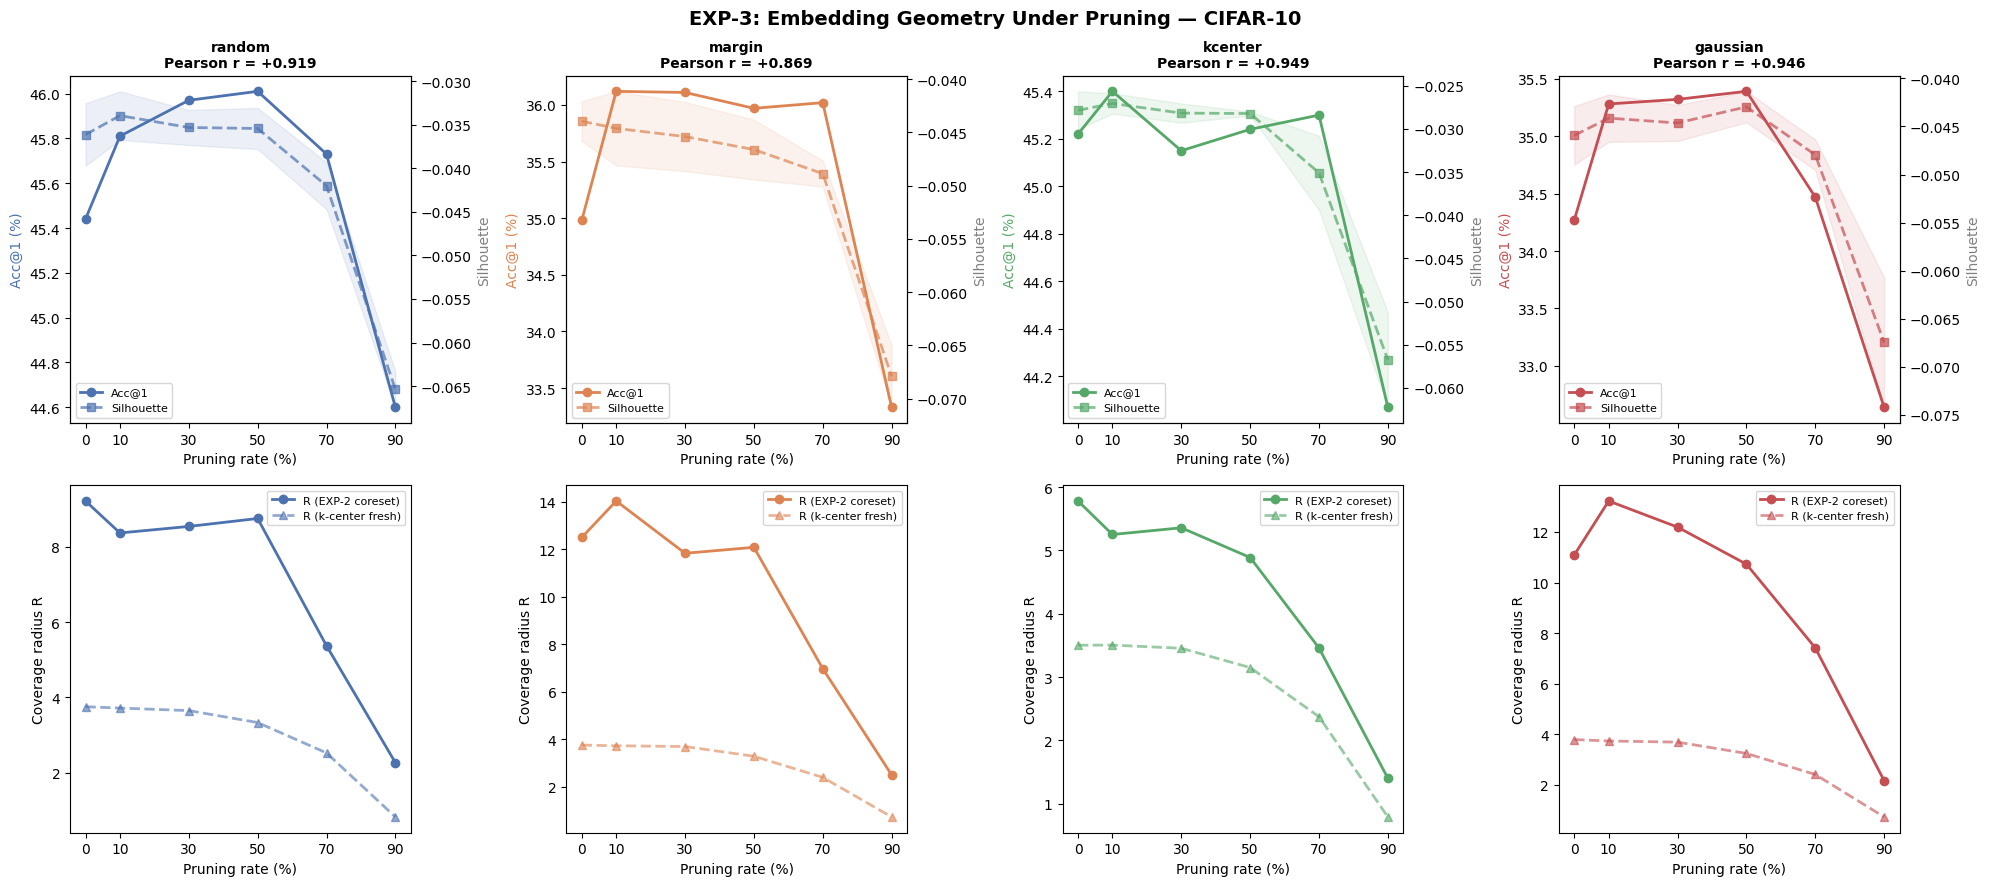

Saved: results/exp3_cifar-10_dual_axis.png


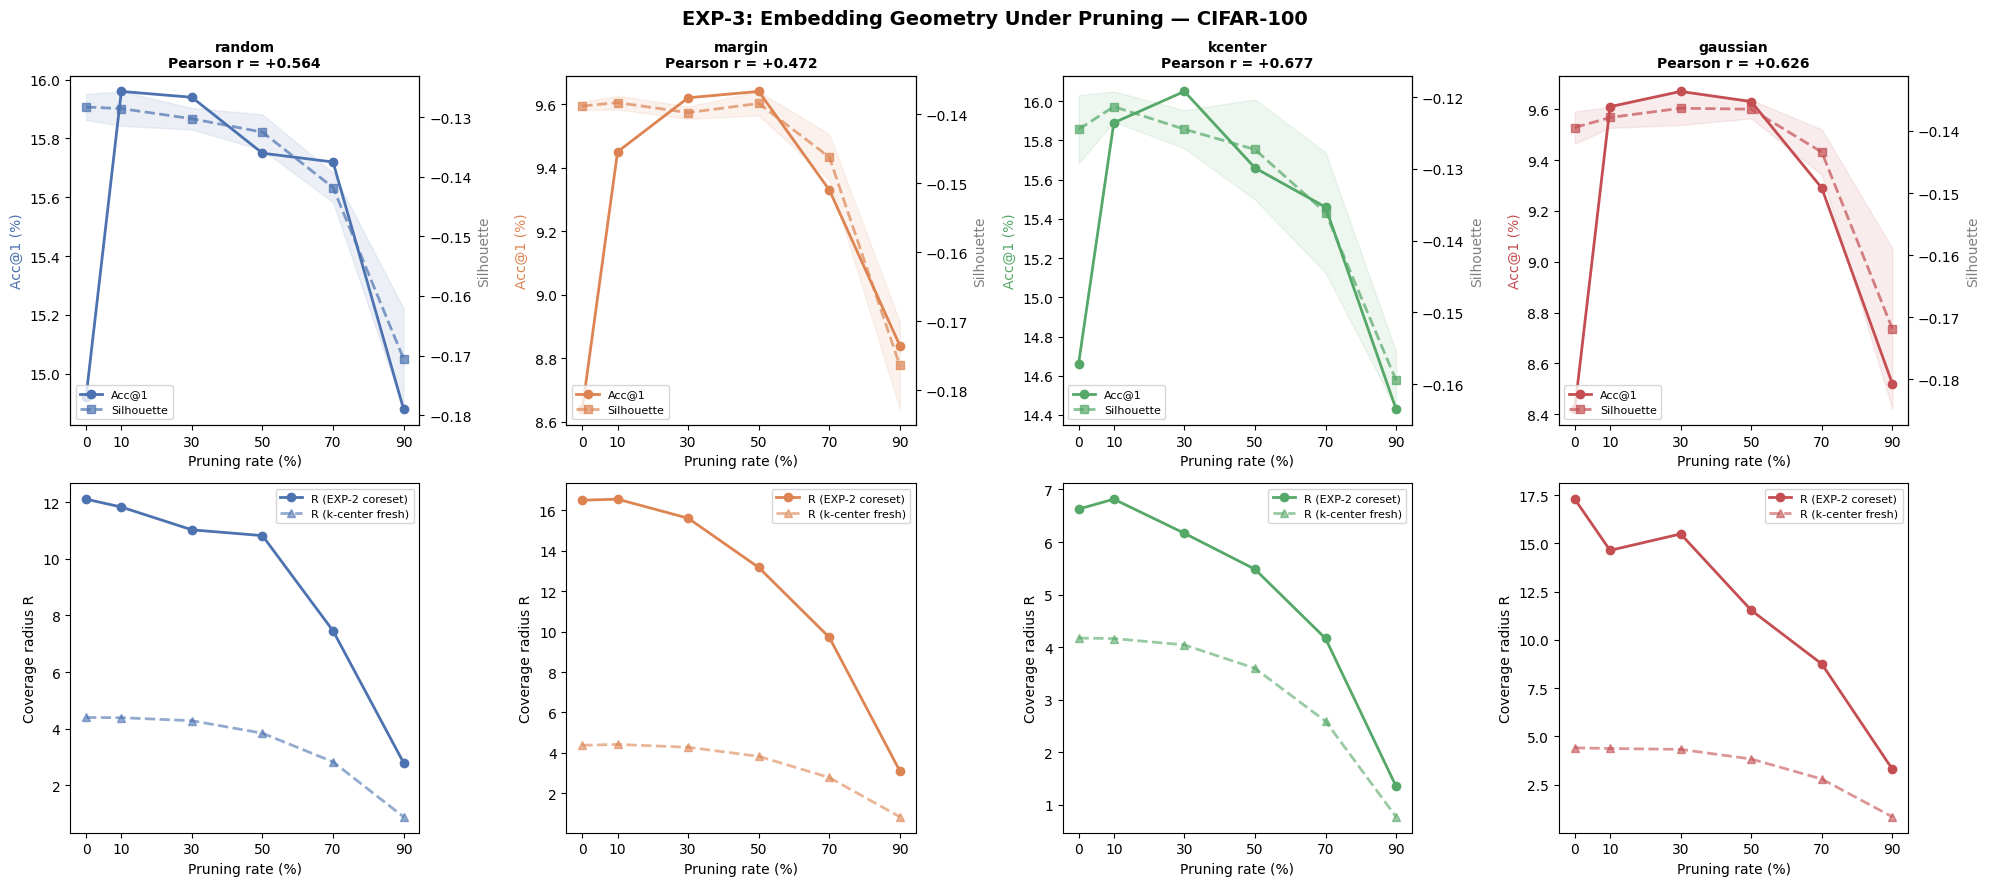

Saved: results/exp3_cifar-100_dual_axis.png


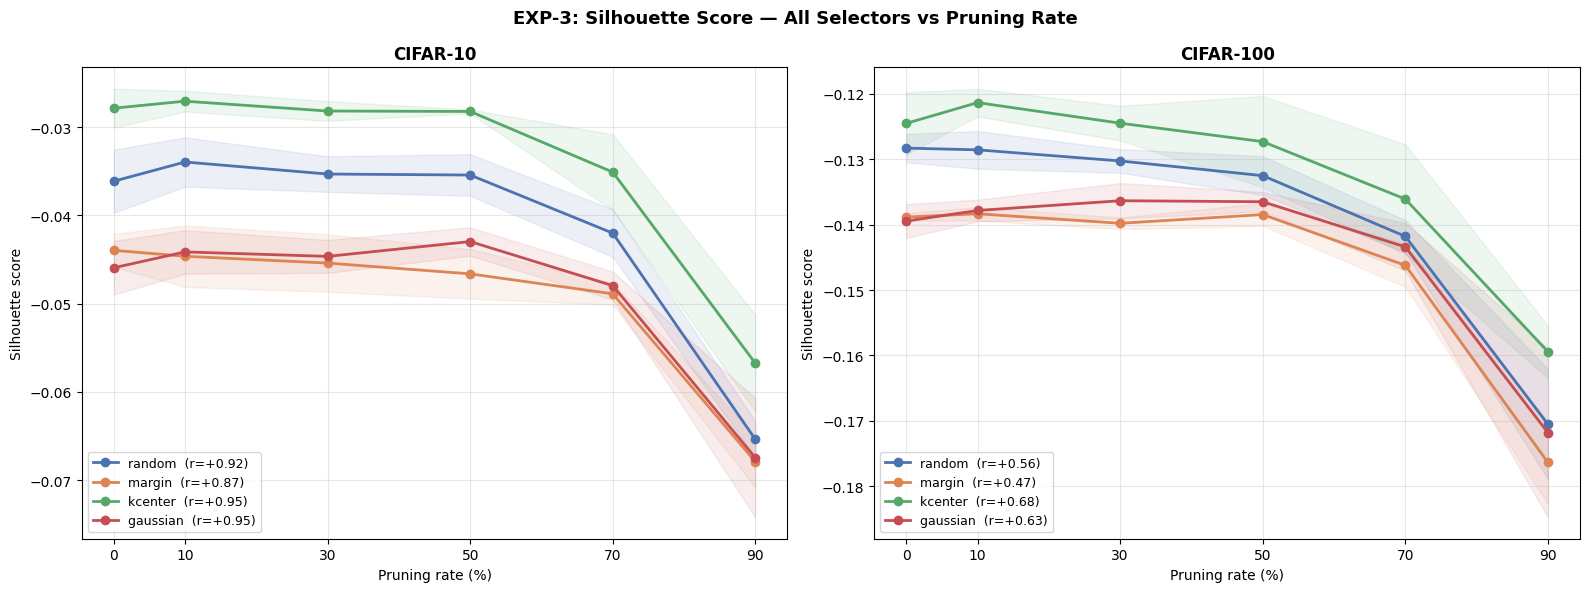

Saved: results/exp3_combined_selectors.png


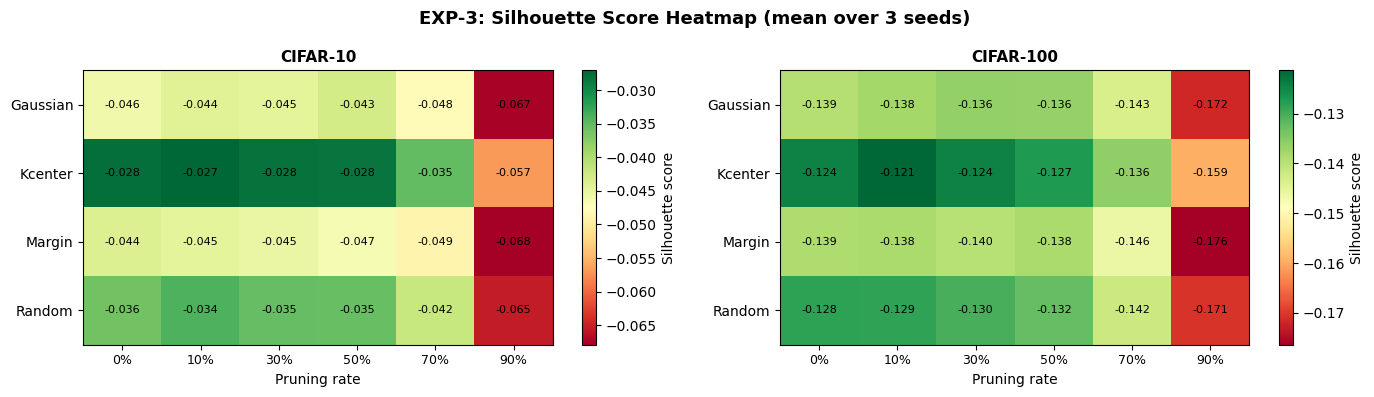

Saved: results/exp3_heatmap.png

=== EXP-3 COMPLETE ===
Output files:
  results/exp3_cifar-100_dual_axis.png
  results/exp3_cifar-10_dual_axis.png
  results/exp3_cifar100_pearson.csv
  results/exp3_cifar100_raw.csv
  results/exp3_cifar100_summary.csv
  results/exp3_cifar10_pearson.csv
  results/exp3_cifar10_raw.csv
  results/exp3_cifar10_summary.csv
  results/exp3_combined_selectors.png
  results/exp3_heatmap.png


In [7]:
# ── CIFAR-10 ───────────────────────────────────────────────────────
df_raw_c10           = run_exp3("cifar10")
merged_c10, pr_c10   = analyse_exp3(df_raw_c10,  "cifar10")

# ── CIFAR-100 ──────────────────────────────────────────────────────
df_raw_c100          = run_exp3("cifar100")
merged_c100, pr_c100 = analyse_exp3(df_raw_c100, "cifar100")

# ── All plots ──────────────────────────────────────────────────────
plot_exp3(merged_c10, merged_c100, pr_c10, pr_c100)

print("\n=== EXP-3 COMPLETE ===")
print("Output files:")
for f in sorted(os.listdir("results")):
    if "exp3" in f:
        print(f"  results/{f}")